In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, r2_score
import pickle # Used for serializing and deserializing Python objects

# 1. Loading Hata

In [63]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")

In [64]:
# Initial Inspection
df.shape

(7043, 21)

In [65]:
import os

# Create a directory to save plots if it doesn't exist
plots_dir = 'plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
print(f"Plots will be saved in the '{plots_dir}' directory.")

Plots will be saved in the 'plots' directory.


## Modified Plotting Functions to Save Plots

In [66]:
pd.set_option("display.max_columns",None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [68]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [69]:
# Dropping customerID column as it is not required for current modelling operations
df=df.drop(columns=['customerID'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
# Printing unique values for each column to understand their distinct categories or range
for cols in df.columns:
  # Display the column name followed by its unique values
  print(cols,":",df[cols].unique())
  print("----------------------->",df[cols].dtype)
  # Separator for better readability between column outputs
  print('-'*50+'XXXX'+'-'*50)

gender : ['Female' 'Male']
-----------------------> object
--------------------------------------------------XXXX--------------------------------------------------
SeniorCitizen : [0 1]
-----------------------> int64
--------------------------------------------------XXXX--------------------------------------------------
Partner : ['Yes' 'No']
-----------------------> object
--------------------------------------------------XXXX--------------------------------------------------
Dependents : ['No' 'Yes']
-----------------------> object
--------------------------------------------------XXXX--------------------------------------------------
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
-----------------------> int64
--------------------------------------------------XXXX-------------------------------------

In [71]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [72]:
df[df['TotalCharges']==" "]
print(len(df[df['TotalCharges']==" "]))

11


In [73]:
# Replacing empty string values in 'TotalCharges' with '0.00' to prepare for numerical conversion.
df['TotalCharges']=df['TotalCharges'].replace({" ":'0.00'})

In [74]:
# ValueError: could not convert string to float: ' '
df['TotalCharges']=df['TotalCharges'].astype(float)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [76]:
# Checking the class distribution of target column (Here, "Churn")
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


# Insights from:
```python
print(df['Churn'].value_counts())
```
- CustomerID removed as it was not required for customer churn prediction.
- No missing values in the dataset,
- Some rows in 'Charges' column has missing values: " ", which were replaced with numerical value '0'.
- Class imbalance observed in the target cell:
['Churn']

# Exploratory Data Analysis

In [77]:
df_col_list=[]
try:
  for col in df.columns:
    if df[col].dtype=='float64' or df[col].dtype=='int64':
      df_col_list.append(col)
  print((df_col_list))
except NameError:
  print("Error: DataFrame 'df' is not defined. Please ensure the cells loading and preprocessing the DataFrame are executed.")

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [78]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# **Numerical Feature Analysis: **
Understanding the distribution of numerical features
python```df.describe()```


In [79]:
def plot_hist(df=df,col=' '):
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True)
  plt.title(f"Distribution of {col}")

  # Calculate the mean and medians
  col_mean=df[col].mean()
  col_median=df[col].median()
  col_mode=df[col].mode()[0] # Access the first mode value
  print(f"Mean: {col_mean}\nMedian: {col_median}\nMode: {col_mode}")
  #Adding vertical lines for mean and median
  plt.axvline(col_mean,color='red',linestyle='dashed',linewidth=2, label='mean')
  plt.axvline(col_median,color='green',linestyle='solid',linewidth=2,label='median')
  plt.axvline(col_mode,color='k',linestyle='dashed',linewidth=2,label='mode')

  plt.tight_layout()
  plt.legend()
  # Save the plot
  plt.savefig(os.path.join(plots_dir, f'hist_{col}.png'))
  plt.show()


Mean: 32.37114865824223
Median: 29.0
Mode: 1


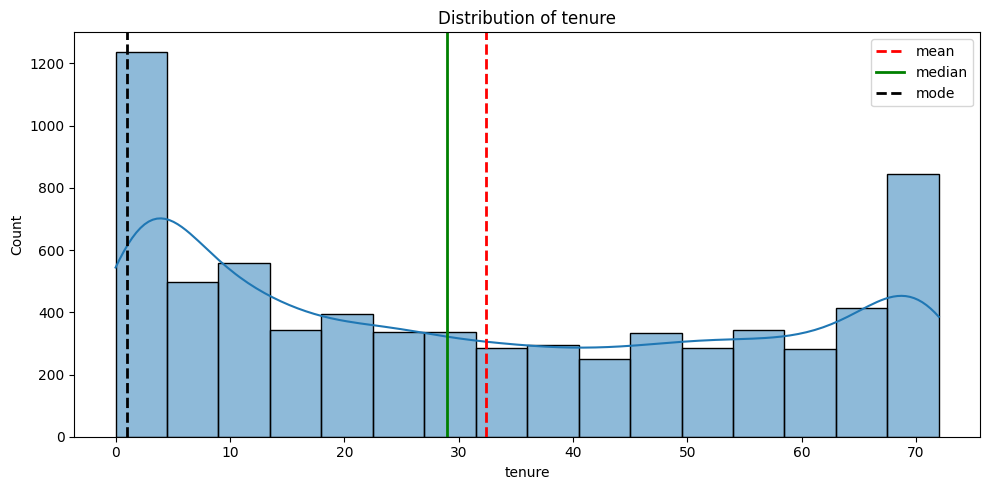

In [80]:
plot_hist(col='tenure')

The distribution for SeniorCitizen

Mean: 0.1621468124378816
Median: 0.0
Mode: 0


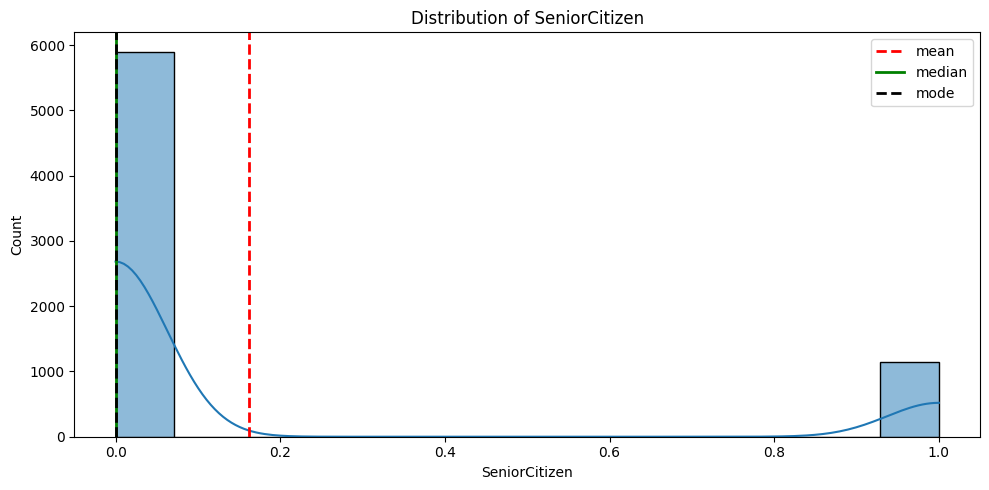

------------------------------ End of distribution for SeniorCitizen ------------------------------
The distribution for tenure

Mean: 32.37114865824223
Median: 29.0
Mode: 1


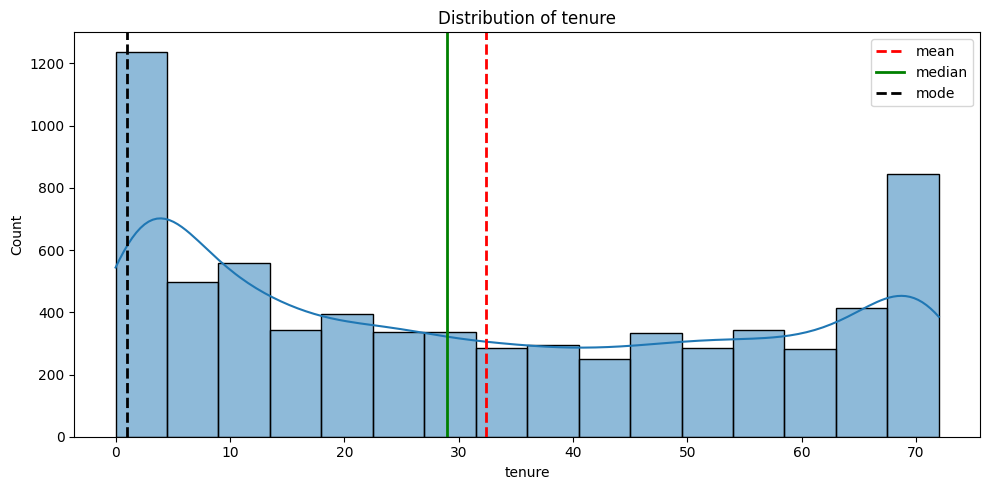

------------------------------ End of distribution for tenure ------------------------------
The distribution for MonthlyCharges

Mean: 64.76169246059918
Median: 70.35
Mode: 20.05


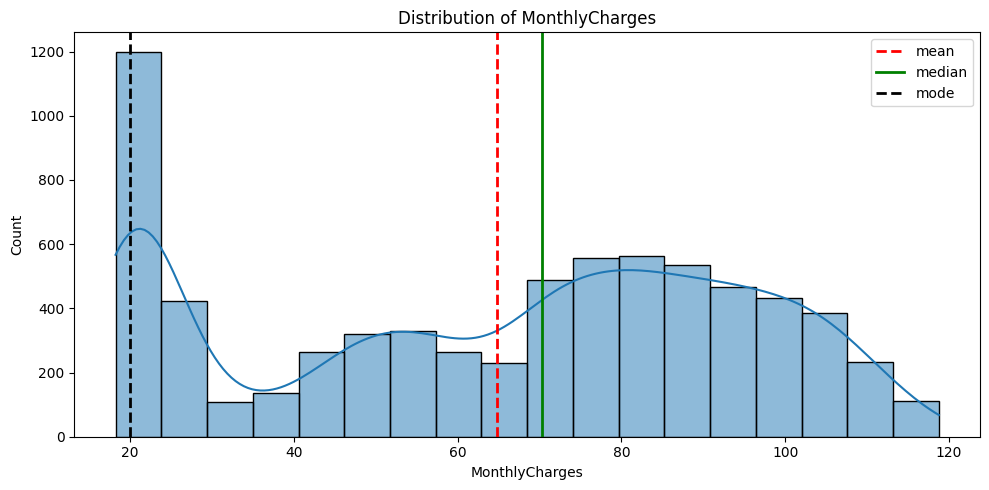

------------------------------ End of distribution for MonthlyCharges ------------------------------
The distribution for TotalCharges

Mean: 2279.7343035638223
Median: 1394.55
Mode: 0.0


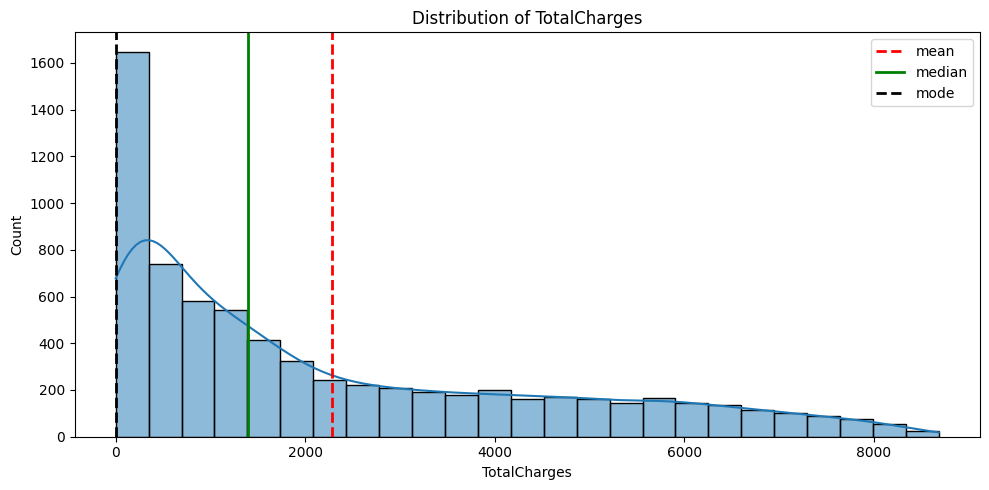

------------------------------ End of distribution for TotalCharges ------------------------------


In [81]:
for i in df_col_list:
  if df[i].dtype=='float64' or df[i].dtype=='int64':
    try:
      print(f'The distribution for {i}\n')
      plot_hist(col=i)
      print('-'*30 + ' End of distribution for ' + i + ' ' + '-'*30)
    except:
      pass
  else:
    continue

# Box Plot for various numerical columns

In [82]:
def box_plot(df, column_name):
  plt.figure(figsize=(10,5))
  sns.boxplot(y=df[column_name], data=df, palette='viridis')
  # Overlay individual data points for better interpretation
  # sns.swarmplot(y=df[column_name], data=df, color='black', alpha=0.7)
  plt.title(f"Box Plot of {column_name} with Data Points")
  plt.ylabel(column_name)
  plt.tight_layout()
  plt.savefig(os.path.join(plots_dir, f'boxplot_{column_name}.png'))
  plt.show()

The distribution for SeniorCitizen



/tmp/ipykernel_373/106034344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], data=df, palette='viridis')


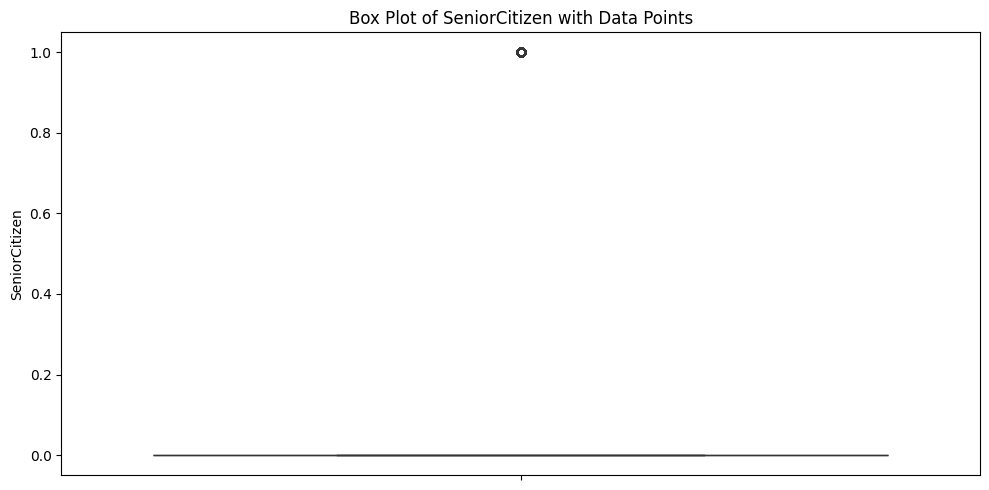

------------------------------ End of distribution for SeniorCitizen ------------------------------
The distribution for tenure



/tmp/ipykernel_373/106034344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], data=df, palette='viridis')


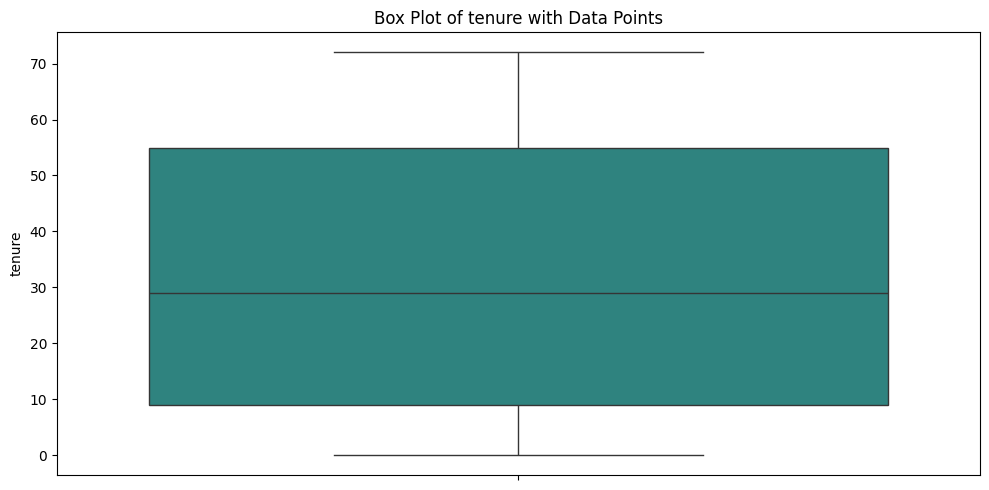

------------------------------ End of distribution for tenure ------------------------------
The distribution for MonthlyCharges



/tmp/ipykernel_373/106034344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], data=df, palette='viridis')


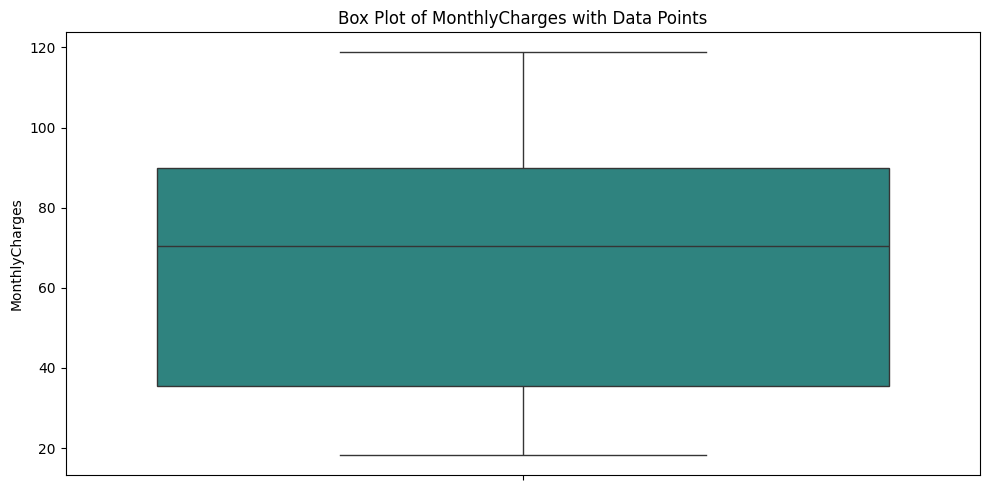

------------------------------ End of distribution for MonthlyCharges ------------------------------
The distribution for TotalCharges



/tmp/ipykernel_373/106034344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], data=df, palette='viridis')


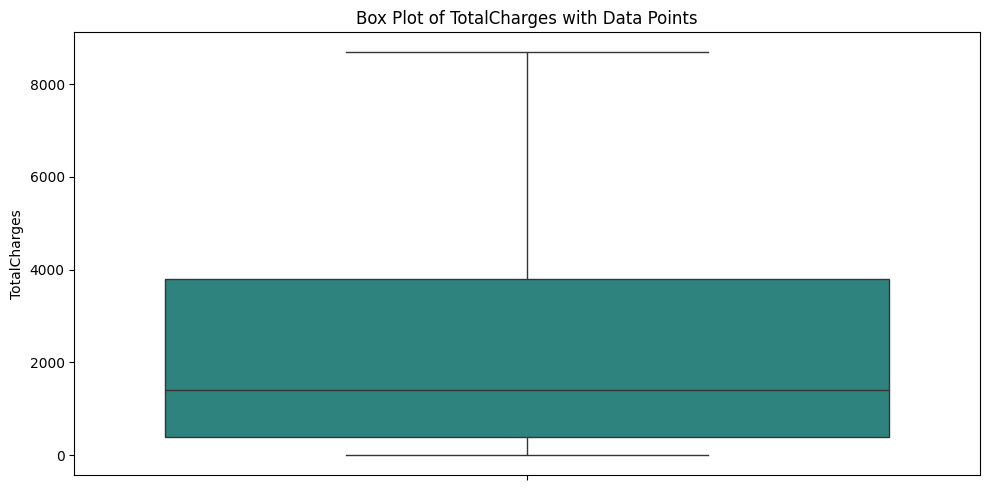

------------------------------ End of distribution for TotalCharges ------------------------------


In [83]:
for i in df_col_list:
  if df[i].dtype=='float64' or df[i].dtype=='int64':
    try:
      print(f'The distribution for {i}\n')
      box_plot(df=df, column_name=i)
      print('-'*30 + ' End of distribution for ' + i + ' ' + '-'*30)
    except:
      pass
  else:
    continue

# **Plotting Correlation Heatmap**

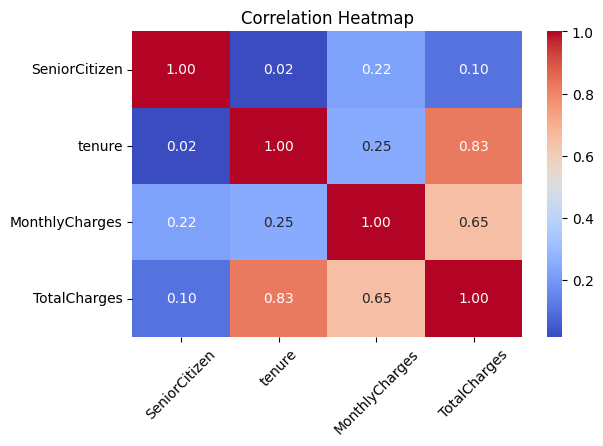

In [84]:
sns.heatmap(df[df_col_list].corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
plt.show()

# **Categorical Column Analysis**

In [85]:
df_categorical=[]
try:
  for col in df.columns:
    if df[col].dtype=='object':
      df_categorical.append(col)
  print((df_categorical))
except NameError:
  print("Error: DataFrame 'df' is not defined. Please ensure the cells loading and preprocessing the DataFrame are executed.")

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


# Count Plots for Categorical Columns

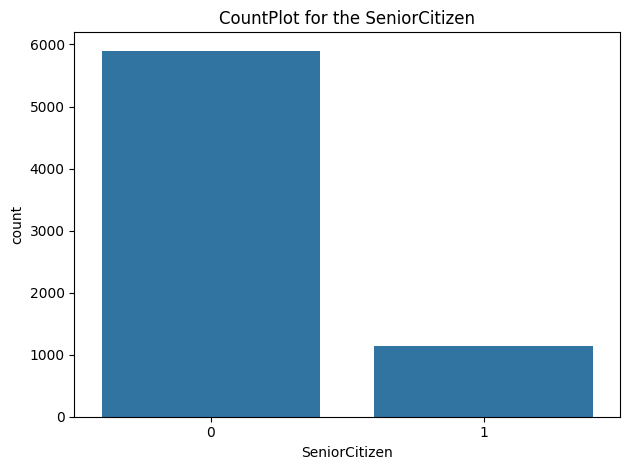

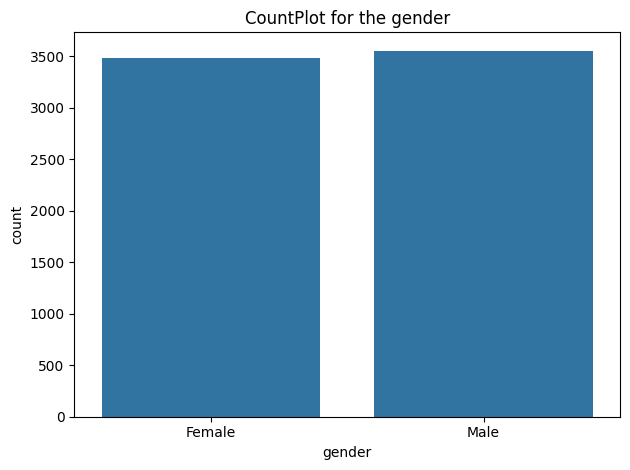

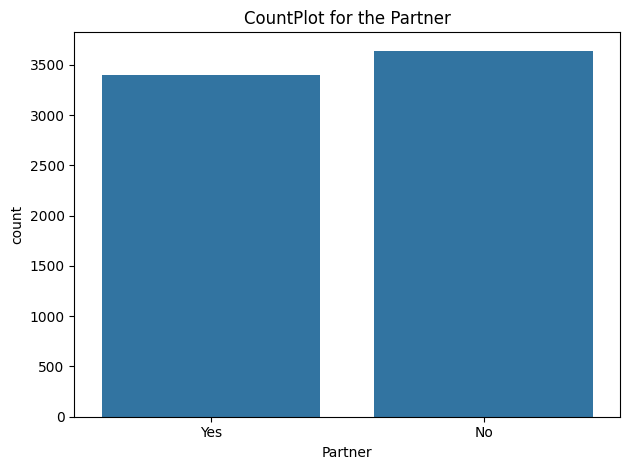

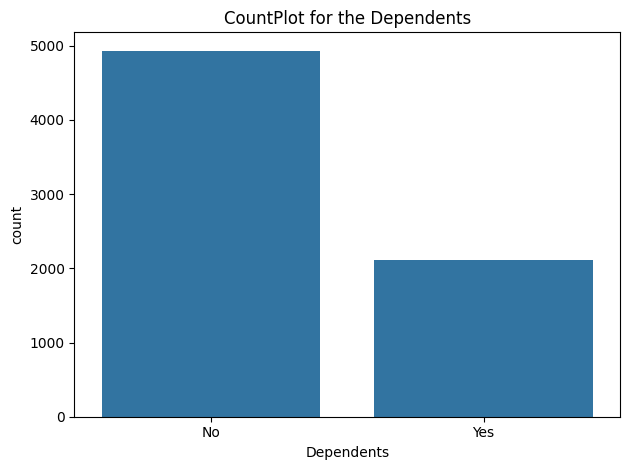

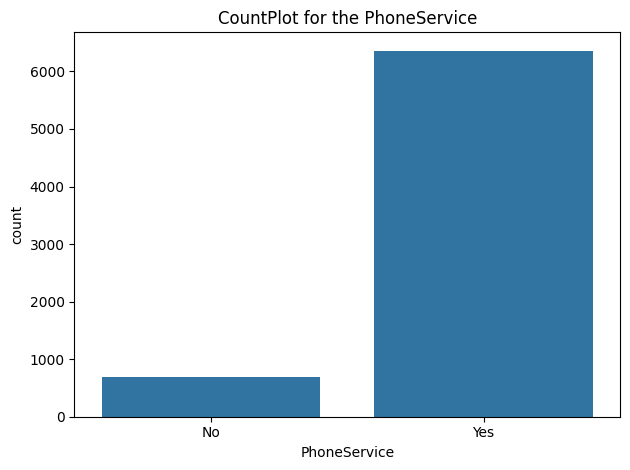

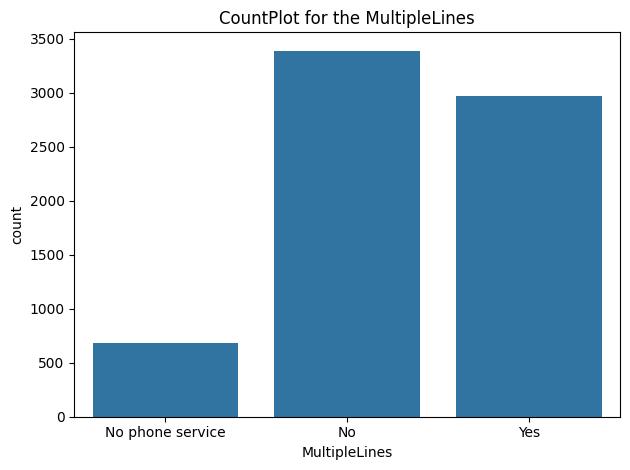

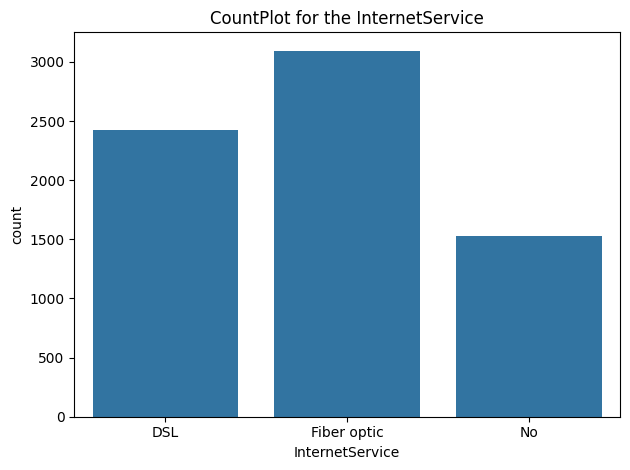

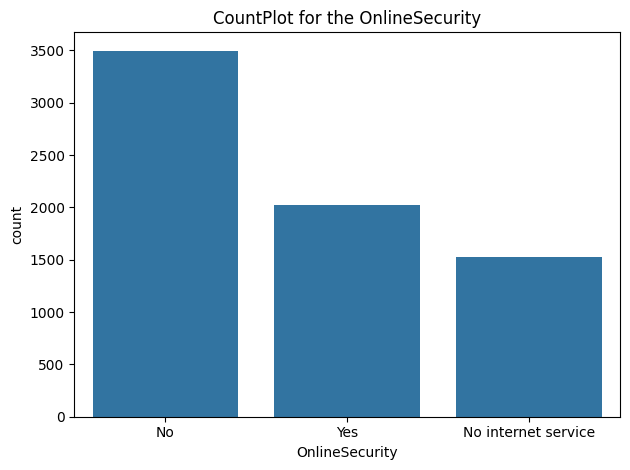

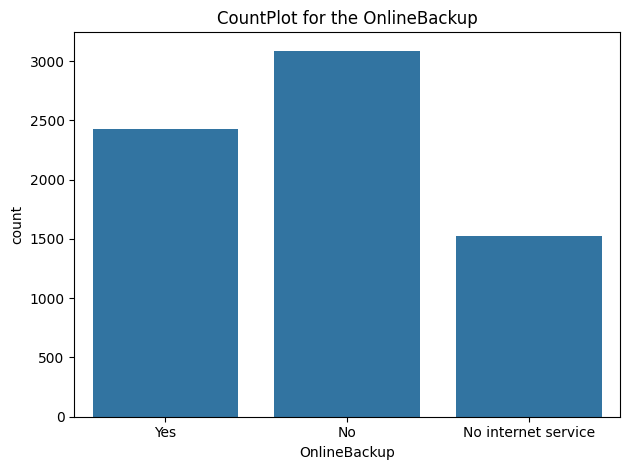

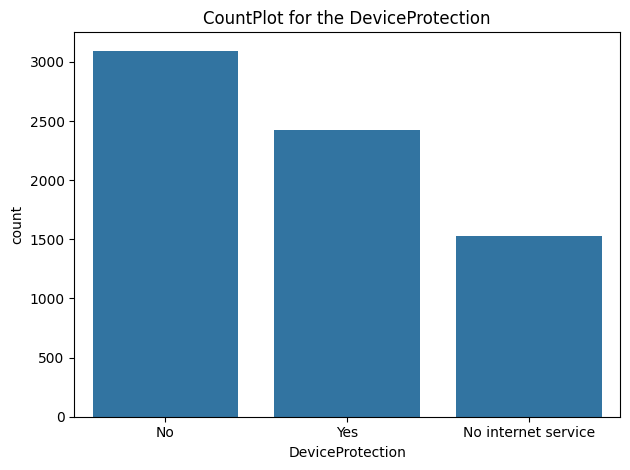

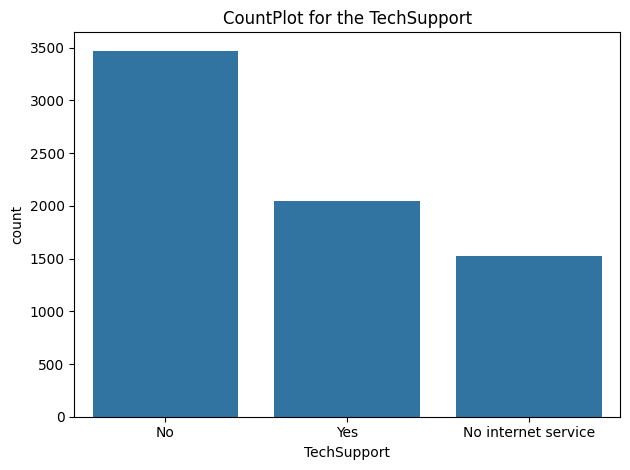

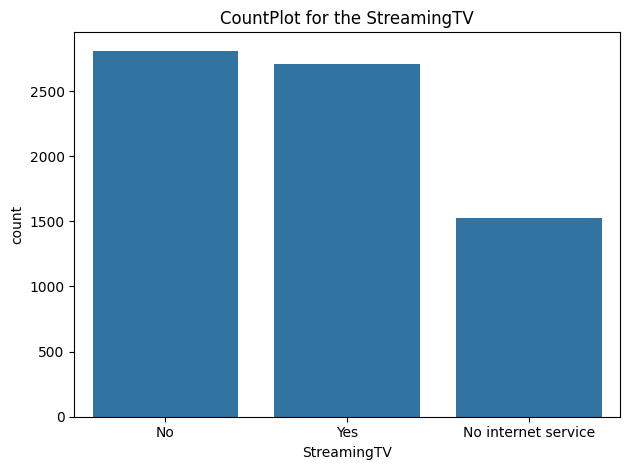

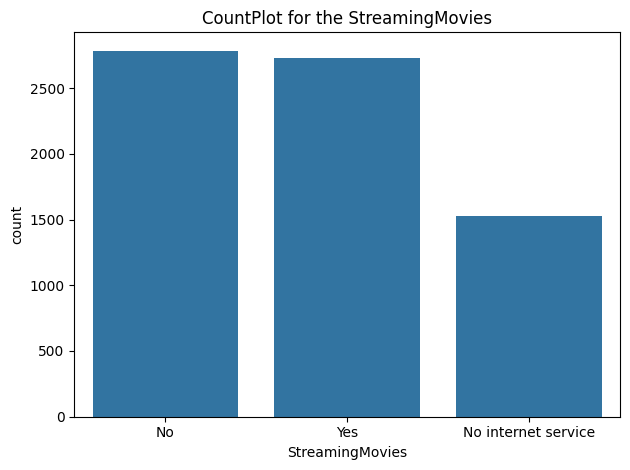

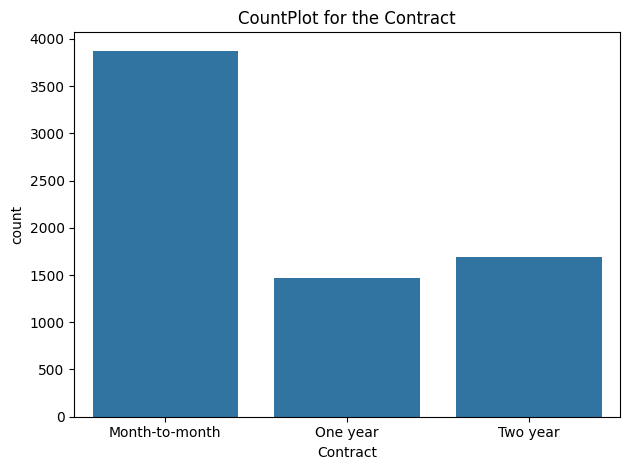

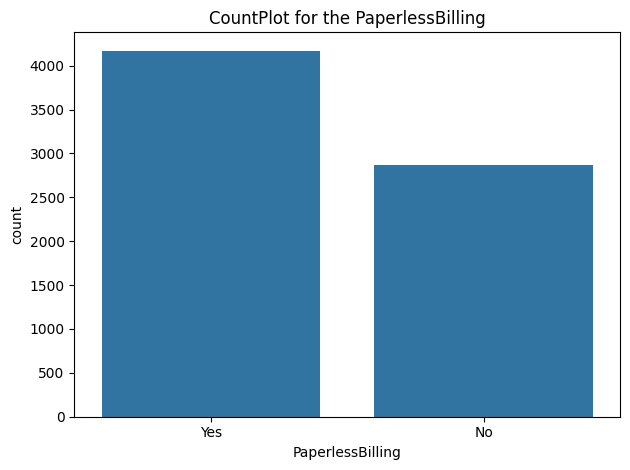

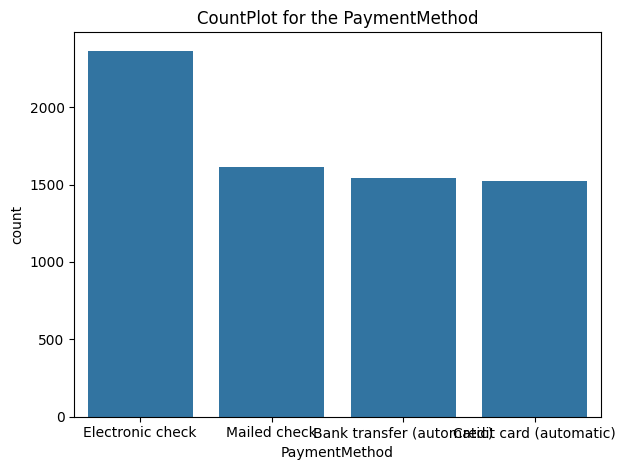

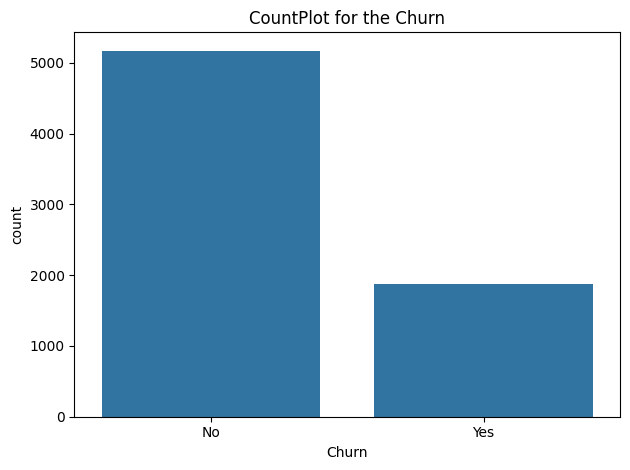

In [86]:
# df_categorical=[]
# df_categorical=df.select_dtypes(include='object').columns.to_list() #"""Alternate Method"""
df_categorical=["SeniorCitizen"]+df_categorical
for col in df_categorical:
  plt.figure()
  sns.countplot(data=df,x=df[col])
  plt.title(f"CountPlot for the {col}")
  plt.tight_layout()
  plt.savefig(os.path.join(plots_dir, f'countplot_{col}.png'))
  plt.show()

# Label Encodin of Target Column

In [87]:
df['Churn']=df['Churn'].replace({'Yes':1, 'No':0})
df.head()

/tmp/ipykernel_373/3393326639.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn']=df['Churn'].replace({'Yes':1, 'No':0})


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [88]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


# Label Encodin of Other Column

In [89]:
obj_cols=df.select_dtypes(include='object').columns.to_list() #"""Alternate Method"""
print(obj_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Pickle File
A .pkl file is a file created using Python's pickle module to store serialized Python objects as a byte stream. This process is known as "pickling," while the reverse process of reconstructing the original objects from the byte stream is called "unpickling".
- wb: Stands for "write binary" mode. When you use {pickle.dump()}
- rb: Stands for "read binary" mode. {pickle.load()}

In [90]:
# Initialize the dictionary to save the encoders
encs={}
le=LabelEncoder()
for cols in obj_cols:
  df[cols]=le.fit_transform(df[cols])
  encs[cols]=le # Store the LabelEncoder instance for the current column

# Saving encoders to pickle file
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(encs, file)

In [91]:
# All categorical datas are converted to categrocial datas
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Train Test Split

In [92]:
# Splitting the features and target
X=df.copy(deep=True)
X=X.drop(columns=['Churn'])
y=df['Churn']
X.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [93]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)
print(f"Total X_train: {X_train.shape}")
print(f"Total X_test: {X_test.shape}")
print(f"Total y_train: {y_train.shape}")
print(f"Total y_test: {y_test.shape}")

Total X_train: (5634, 19)
Total X_test: (1409, 19)
Total y_train: (5634,)
Total y_test: (1409,)


In [94]:
# Checking the class distribution of the target variable in the training set
print(y_train.value_counts('y_train'))
# Checking the class distribution of the target variable in the testing set
print(y_test.value_counts('y_test'))

Churn
0    0.738729
1    0.261271
Name: proportion, dtype: float64
Churn
0    0.71824
1    0.28176
Name: proportion, dtype: float64


# Performing Synthetic Minority Oversampling Technique

In [95]:
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
print(X_train_smote.shape)
print()
print(y_train_smote.shape)


(8324, 19)

(8324,)


In [96]:
print(X_train_smote.value_counts())
print()
print(y_train_smote.value_counts())


gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges
0       0              0        0           1       1             0              2                1               1             1                 1            1            1                0         1                 0              20.200000       20.200000       4
1       0              0        0           1       1             0              2                1               1             1                 1            1            1                0         0                 3              20.200000       20.200000       4
0       0              1        0           1       0             1              0                0               0             0                 0            0            0                0         1       

# **Training with default parameters**

In [97]:
models={
    "Decision Tree": DecisionTreeClassifier(random_state=24),
    "Random Forest": RandomForestClassifier(random_state=24),
    "XGBoost" : XGBRFClassifier(random_state=24)
}

In [98]:
# Dictionary to store the cross validation results for each model
cv_scores_orgdata={}

# Performing 5-fold cross validation for each model defined in the 'models' dictionary
for model_name,model in models.items():
  print(f"Training {model_name} with default parameters")
  # Perform cross-validation with 5 folds using SMOTE-resampled training data and 'accuracy' as the scoring metric
  scores=cross_val_score(model,X_train,y_train,cv=5, scoring='accuracy')
  # Store the cross-validation scores for the current model
  cv_scores_orgdata[model_name]=scores
  # Print the average cross-validation accuracy for the current model, formatted to two decimal places
  print(f"Cross Validation Accuracy for eithout applying SMOTE{model_name}: {np.mean(scores):.2f}")

Training Decision Tree with default parameters
Cross Validation Accuracy for eithout applying SMOTEDecision Tree: 0.74
Training Random Forest with default parameters
Cross Validation Accuracy for eithout applying SMOTERandom Forest: 0.79
Training XGBoost with default parameters
Cross Validation Accuracy for eithout applying SMOTEXGBoost: 0.80


In [99]:
# Dictionary to store the cross validation results for each model
cv_scores={}

# Performing 5-fold cross validation for each model defined in the 'models' dictionary
for model_name,model in models.items():
  print(f"Training {model_name} with default parameters")
  # Perform cross-validation with 5 folds using SMOTE-resampled training data and 'accuracy' as the scoring metric
  scores=cross_val_score(model,X_train_smote,y_train_smote,cv=5, scoring='accuracy')
  # Store the cross-validation scores for the current model
  cv_scores[model_name]=scores
  # Print the average cross-validation accuracy for the current model, formatted to two decimal places
  print(f"Cross Validation Accuracy for {model_name}: {np.mean(scores):.2f}")

Training Decision Tree with default parameters
Cross Validation Accuracy for Decision Tree: 0.79
Training Random Forest with default parameters
Cross Validation Accuracy for Random Forest: 0.84
Training XGBoost with default parameters
Cross Validation Accuracy for XGBoost: 0.82


In [100]:
print(f"Scores without applying SMOTE\n")
cv_scores_orgdata

Scores without applying SMOTE



{'Decision Tree': array([0.74889086, 0.75066548, 0.71428571, 0.73824312, 0.73179396]),
 'Random Forest': array([0.80567879, 0.7985803 , 0.76042591, 0.80390417, 0.79662522]),
 'XGBoost': array([0.8136646 , 0.80212955, 0.7755102 , 0.81898846, 0.79484902])}

In [101]:
print(f"Scores after applying SMOTE \n")
cv_scores

Scores after applying SMOTE 



{'Decision Tree': array([0.6954955 , 0.73993994, 0.82342342, 0.83303303, 0.84495192]),
 'Random Forest': array([0.72552553, 0.77417417, 0.87327327, 0.91831832, 0.90805288]),
 'XGBoost': array([0.74834835, 0.77297297, 0.84324324, 0.86186186, 0.87019231])}

**Inferences from above model training**\
The random forest performed the best with default parameters, i.e. highest accuracy

In [102]:
rfc=RandomForestClassifier(random_state=24)
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier(random_state=24)

# Model Evaluation


In [103]:
y_pred=rfc.predict(X_test)

In [104]:
print(y_test.value_counts())

Churn
0    1012
1     397
Name: count, dtype: int64


In [105]:
print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy Score: 0.7636621717530163

Confusion Matrix:
 [[867 145]
 [188 209]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1012
           1       0.59      0.53      0.56       397

    accuracy                           0.76      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.76      0.76      1409



In [106]:
model_data={'model': rfc, "feature_names":X.columns.to_list()}
with open("Customer_Churn_Prediction.pkl","wb") as f:
  pickle.dump(model_data,f)

# **Loading the saved model and building the predictive system**

In [107]:
import pickle
from sklearn.preprocessing import LabelEncoder

encs = {}
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encs[col] = le

# Save the properly fitted encoders
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(encs, file)

In [108]:
print(loaded_model)

RandomForestClassifier(random_state=24)


In [109]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


# Churn
Customer churn in prediction models refers to the loss of clients or subscribers who stop using a company’s product or service over a specific period. It is the opposite of retention, representing the rate of customer attrition (often measured as a percentage) that directly affects revenue, indicating potential dissatisfaction or service cancellation.\
- Significance: It is a key metric for subscription-based businesses (SaaS) to measure loyalty and financial health.

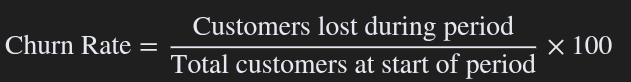